In [3]:
import numpy as np
import geopandas as gpd
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [4]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
TEST_YEAR = '2022'
TEST_MONTH = '7'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [5]:
trained_model = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Trained_Model.pkl', 'rb'))
scaler = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Scaler.pkl', 'rb'))
imputer = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Imputer.pkl', 'rb'))
feature_names = pickle.load(open(f'../../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_2010-2023_WNV_Feature_List.pkl', 'rb'))

In [6]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 Level/Greece/data'

test_file = f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv'
data_test = read_data(test_file)
data_test.reset_index(drop = True, inplace = True)
print(data_test.shape)

(1176, 112)


In [7]:
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.0,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.0,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.0,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844

In [8]:
data_test = data_test[data_test['year'] == 2022]
data_test.reset_index(drop=True, inplace=True)
data_test.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2022,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.096063,11.331601,16.189056,16.189056,NaN,0.686249,2.871587,1.710155,1.710155,NaN,3.891156,7.101594,8.949606,8.949606,-0.057713,12.505934,3.092031,26.162765,28.869690,95.813383,1082.033272,257.814815,8.316607,16.500000,19.666667,47.967480,811.564146,37.0,-4.0,41.0,9.166667,24.500000,25.333333,5.666667,1075.0,375.0,29.0,103.908908,551.0,124.0,129.0,529.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,10403.0,43724.0,15248.0,69375.0,9806.0,42927.0,18730.0,71463.0,1529.23,1706.0,2112.0,0
1,EL522,2022,1,23.139033,40.693632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.339037,12.820575,16.549486,16.549486,NaN,-0.077253,3.425273,3.056729,3.056729,NaN,4.130892,8.122924,9.803107,9.803107,0.927160,12.982073,6.751537,56.162193,56.242801,209.297656,1395.812299,78.414062,2.529486,17.500000,21.000000,45.652174,913.285776,42.0,-4.0,46.0,9.000000,27.000000,28.000000,5.833333,1390.0,348.0,22.0,99.062326,626.0,119.0,122.0,604.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,79433.0,343553.0,98724.0,521710.0,76364.0,367004.0,131587.0,574955.0,14404.36,21757.0,19223.0,0
2,EL523,2022,1,22.762317,41.016275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.166427,13.574627,17.217314,17.217314,NaN,-0.979642,2.749992,2.731781,2.731781,NaN,3.593392,8.162310,9.974548,9.974548,-0.941242,12.649775,4.440942,21.768787,22.124398,137.669194,1340.390926,82.434783,2.659187,18.000000,22.500000,45.000000,957.506231,44.0,-6.0,50.0,9.666667,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,5585.0,26233.0,8895.0,40713.0,5279.0,22456.0,11149.0

In [9]:
data_test = encode_cyclical(data_test, 'month', 12)

In [10]:
len(data_test.NUTS3_ID.unique())

7

In [11]:
data_test = data_test.query(f'month == {TEST_MONTH}')
data_test.reset_index(drop=True, inplace=True)

In [12]:
data_test.head(10)

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases,month_sin,month_cos
0,EL521,2022,7,22.217953,40.552111,0.569148,0.168634,-0.496102,-0.168634,0.544234,0.169193,-0.471900,-0.169193,0.059889,0.047874,0.044866,0.047874,30.561558,7.601435,11.950384,11.829689,11.829689,20.165709,-0.386828,1.015083,0.224198,0.224198,25.363633,3.607304,6.590378,6.026944,6.026944,17.309630,35.135926,6.789113,26.295554,53.469139,203.673376,590.004804,1262.037037,42.067901,16.500000,19.666667,47.967480,811.564146,37.0,-4.0,41.0,9.166667,24.500000,25.333333,5.666667,1075.0,375.0,29.0,103.908908,551.0,124.0,129.0,529.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,10403.0,43724.0,15248.0,69375.0,9806.0,42927.0,18730.0,71463.0,1529.23,1706.0,2112.0,0,-0.5,-0.866025
1,EL522,2022,7,23.139033,40.693632,0.411215,0.108795,-0.371845,-0.108795,0.386678,0.105055,-0.347631,-0.105055,0.071107,0.058978,0.060459,0.058978,31.911923,7.681866,12.594721,13.316265,13.316265,19.059068,0.336245,1.643968,0.934617,0.934617,25.485496,4.009056,7.119344,7.125441,7.125441,16.168281,36.086406,6.032154,12.046105,34.281424,180.964631,646.823791,1136.351562,37.878385,17.500000,21.000000,45.652174,913.285776,42.0,-4.0,46.0,9.000000,27.000000,28.000000,5.833333,1390.0,348.0,22.0,99.062326,626.0,119.0,122.0,604.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,79433.0,343553.0,98724.0,521710.0,76364.0,367004.0,131587.0,574955.0,14404.36,21757.0,19223.0,11,-0.5,-0.866025
2,EL523,2022,7,22.762317,41.016275,0.407366,0.035451,-0.402190,-0.035451,0.404767,0.040459,-0.397110,-0.040459,0.058273,0.047342,0.039030,0.047342,33.992084,8.170406,13.848129,14.804523,14.804523,18.574228,-0.505827,1.129519,0.181038,0.181038,26.283156,3.832289,7.488824,7.492781,7.492781,15.600870,40.326957,4.712974,5.208052,30.437249,141.389229,516.190962,1301.043478,43.368116,18.000000,22.500000,45.000000,957.506231,44.0,-6.0,50.0,9.666667,28.166667,29.166667,5.666667,1333.0,348.0,24.0,95.733373,569.0,119.0,128.0,543.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180

In [13]:
features = data_test.loc[:, data_test.columns.isin(feature_names)].columns
print(features.to_list())

print(f"Total Features Used: {len(features)}")

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']
Total Features Used: 64


In [14]:
X_test = data_test.loc[:, data_test.columns.isin(feature_names)]
y_test = data_test['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.fit_transform(X_test_scaled)

y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

In [15]:
results = pd.concat([data_test.iloc[:, :5], pd.Series(y_test_prob, name='score')], axis=1)

In [16]:
results.sort_values(by='score', ascending=False).head(5)

,NUTS3_ID,year,month,x,y,score
1,EL522,2022,7,23.139033,40.693632,0.977046
0,EL521,2022,7,22.217953,40.552111,0.816678
5,EL526,2022,7,23.544035,41.084331,0.663012
3,EL524,2022,7,22.109782,40.888821,0.564249
4,EL525,2022,7,22.442423,40.269959,0.551756


In [17]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"

greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_Whole.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')

In [18]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == NUTS2_ID]
greece_nuts3_gdf.drop(columns=['CNTR_CODE','CNTR_NAME','NUTS1_ID','NUTS1_LATN','NUTS1_NAME','NUTS2_ID','NUTS2_LATN','NUTS2_NAME', 'NUTS3_LATN', 'MOUNT_TYPE','URBN_TYPE','COAST_TYPE'], inplace=True)
greece_nuts3_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

greece_nuts2 CRS: EPSG:4326
greece_nuts3 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326


In [19]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [20]:
greece_nuts3_gdf.head()

,NUTS3_ID,NUTS3_NAME,geometry
0,EL521,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


In [21]:
greece_lau1.head()

,NAME,geometry
0,Δέλτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
1,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
2,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
3,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
4,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [22]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256...",0
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087...",1
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40...",2
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179...",3
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039...",4


In [23]:
results = pd.merge(results, greece_nuts3_gdf, on='NUTS3_ID', how='left')
results = gpd.GeoDataFrame(results, geometry='geometry')
results['x'] = results['x'].round(4)
results['y'] = results['y'].round(4)
results.rename(columns={'score': 'risk_score'}, inplace=True)
results['risk_score'] = results['risk_score'].round(6)

In [24]:
type(results)

geopandas.geodataframe.GeoDataFrame

In [25]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL521,2022,7,22.2180,40.5521,0.816678,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,2022,7,23.1390,40.6936,0.977046,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,2022,7,22.7623,41.0163,0.514108,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,2022,7,22.1098,40.8888,0.564249,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,2022,7,22.4424,40.2700,0.551756,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
5,EL526,2022,7,23.5440,41.0843,0.663012,Σέρρες,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
6,EL527,2022,7,23.5315,40.3634,0.494924,Χαλκιδική,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."


In [26]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

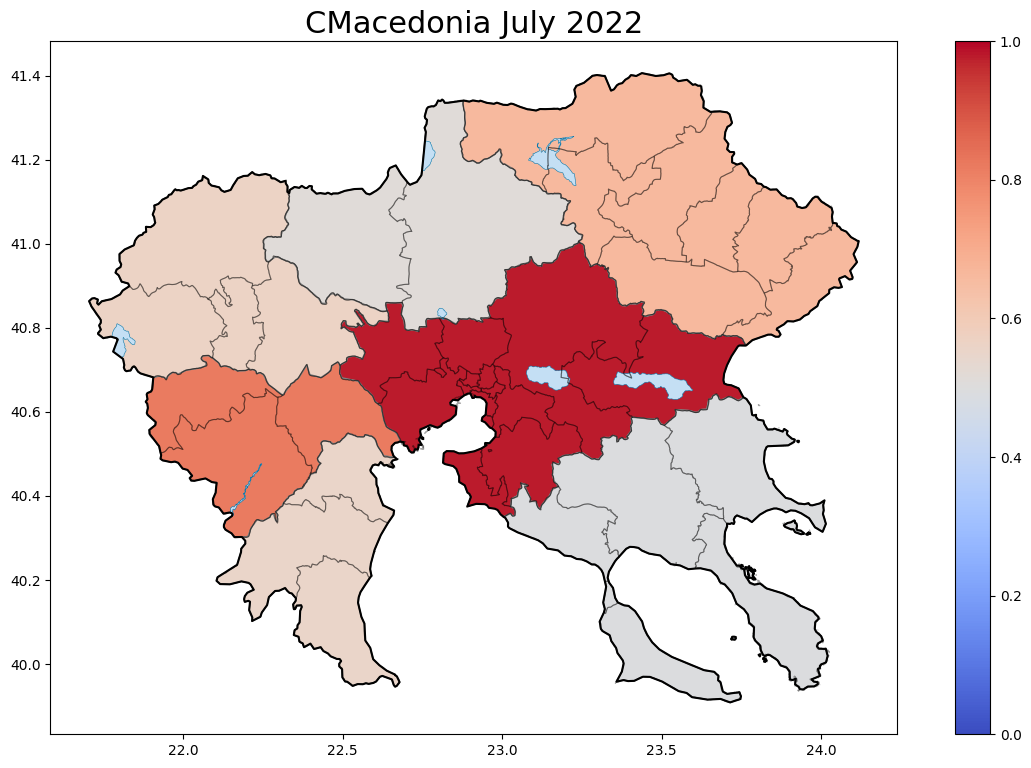

In [27]:
fig, ax = plt.subplots(figsize=figure_size)

# Plot the geometry column with the colors based on the float column
results.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)


plt.title(f'{NUTS2} {month_dict.get(results.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [34]:
fig = interactive_colored_mapbox(results, greece_lakes, greece_nuts3_gdf, #greece_lau1, 
                                 index_col=None, color_col='risk_score', hover_name='NUTS3_NAME', 
                                 hover_data={'risk_score':True, 'x': True, 'y': True, 'NUTS3_ID': True}, 
                                 center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
                                         'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
                                 zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, fig_title = '[EL52]Central Macedonia - July 2022',
                                 index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
                                 hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=670, fig_width=1000, size_f5=6.5)

fig.show()

In [29]:
results

,NUTS3_ID,year,month,x,y,risk_score,NUTS3_NAME,geometry
0,EL521,2022,7,22.2180,40.5521,0.816678,Ημαθία,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
1,EL522,2022,7,23.1390,40.6936,0.977046,Θεσσαλονίκη,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
2,EL523,2022,7,22.7623,41.0163,0.514108,Κιλκίς,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
3,EL524,2022,7,22.1098,40.8888,0.564249,Πέλλα,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
4,EL525,2022,7,22.4424,40.2700,0.551756,Πιερία,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."
5,EL526,2022,7,23.5440,41.0843,0.663012,Σέρρες,"POLYGON ((23.62422 41.37573, 23.62617 41.36319..."
6,EL527,2022,7,23.5315,40.3634,0.494924,Χαλκιδική,"MULTIPOLYGON (((23.75687 40.63456, 23.76634 40..."


In [30]:
results[['NUTS3_ID', 'NUTS3_NAME', 'year', 'month', 'risk_score']]

,NUTS3_ID,NUTS3_NAME,year,month,risk_score
0,EL521,Ημαθία,2022,7,0.816678
1,EL522,Θεσσαλονίκη,2022,7,0.977046
2,EL523,Κιλκίς,2022,7,0.514108
3,EL524,Πέλλα,2022,7,0.564249
4,EL525,Πιερία,2022,7,0.551756
5,EL526,Σέρρες,2022,7,0.663012
6,EL527,Χαλκιδική,2022,7,0.494924


In [31]:
#results.to_file(f'../../../data/{NUTS2}/predictions/GR_{NUTS2}_NUTS3_Predictions_June_2024.shp', encoding = 'utf-8')